In [ ]:
# import Pkg
# Pkg.develop(path=pwd())

In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `~/Documents/RVSDDP`


In [3]:
using Revise
using RVSDDP
using Random
using Plots
using Gurobi
using CSV
using DataFrames
using Statistics
using Distributions
# using HiGHS
# optimizer = () -> HiGHS.Optimizer()
using Gurobi
const GRB_ENV = Gurobi.Env()
optimizer=() -> Gurobi.Optimizer(GRB_ENV)

Set parameter Username
Set parameter LicenseID to value 2818369
Academic license - for non-commercial use only - expires 2027-05-05


#35 (generic function with 1 method)

In [4]:
function subproblem_builder(subproblem::Model, node::Int, discount_factor::Float64)
    # State variables
    N=1
    @variable(subproblem, 0 <= volume[1:N] <= 200, RVSDDP.State, initial_value = 50)
    # Control variables
    @variables(subproblem, begin
        thermal_generation[1:4] >= 0
        thermal_generation_tot >= 0
        hydro_generation[1:N] >= 0
        hydro_spill[1:N] >= 0
        deficit >= 0
    end)
    # Random variables
    @variable(subproblem, inflow)
    Ω = [20.0, 80.0]
    # Ω = [40.0]
    P = [1 / length(Ω) for _ in Ω]
    # Ω = [70.0]
    # P = [1.0]
    RVSDDP.parameterize(subproblem, Ω, P) do ω
        return JuMP.fix(inflow, ω)
    end

    capa_th = [10 15 10 5] 
    c_th = [1 2 5 10]
    # Transition function and constraints
    @constraints(
        subproblem,
        begin
            [i in 1:N], volume[i].out == volume[i].in - hydro_generation[i] - hydro_spill[i] + inflow
            [i in 1:N], hydro_generation[i] <= 100
            [i in 1:1], thermal_generation[i] <= capa_th[i]
            thermal_generation_tot==sum(thermal_generation[i] for i in 1:4)
            deficit + sum(hydro_generation[i] for i in 1:N) + thermal_generation_tot == 60+0*node
        end
    )
    # Stage-objective
    @stageobjective(subproblem, 1*(50*sum(hydro_spill[i] for i in 1:N) + 50 * deficit+ sum(thermal_generation[i]*c_th[i] for i in 1:4)))
    return subproblem
end

subproblem_builder (generic function with 1 method)

In [5]:
seed_list = 1:10
iter_max = 100
iter_list_value = 10:100
iter_list_oos = 10:10:100
shift_list = [RVSDDP.no_shift, RVSDDP.shift_update_random_forward]
discount_factor=0.99
period = 1
N=1000

1000

In [6]:
graph=RVSDDP.InfiniteLinearGraph(1);

In [9]:
    model_no_shift = RVSDDP.PolicyGraph(
        subproblem_builder,
        graph;
        sense = :Min,
        lower_bound = 0.0,
        optimizer = optimizer,
        discount_factor=discount_factor,
    )

    folder = "results_toy/no_shift/$(discount_factor)/seed_1_iter_$(iter_max)" 

    RVSDDP._add_cuts(model_no_shift, iter_max, folder);

    model_RVSDDP = RVSDDP.PolicyGraph(
        subproblem_builder,
        graph;
        sense = :Min,
        lower_bound = 0.0,
        optimizer = optimizer,
        discount_factor=discount_factor,
    )

    folder = "results_toy/shift_update_random_forward/$(discount_factor)/seed_1_iter_$(iter_max)" 

    RVSDDP._add_cuts(model_RVSDDP, iter_max, folder);

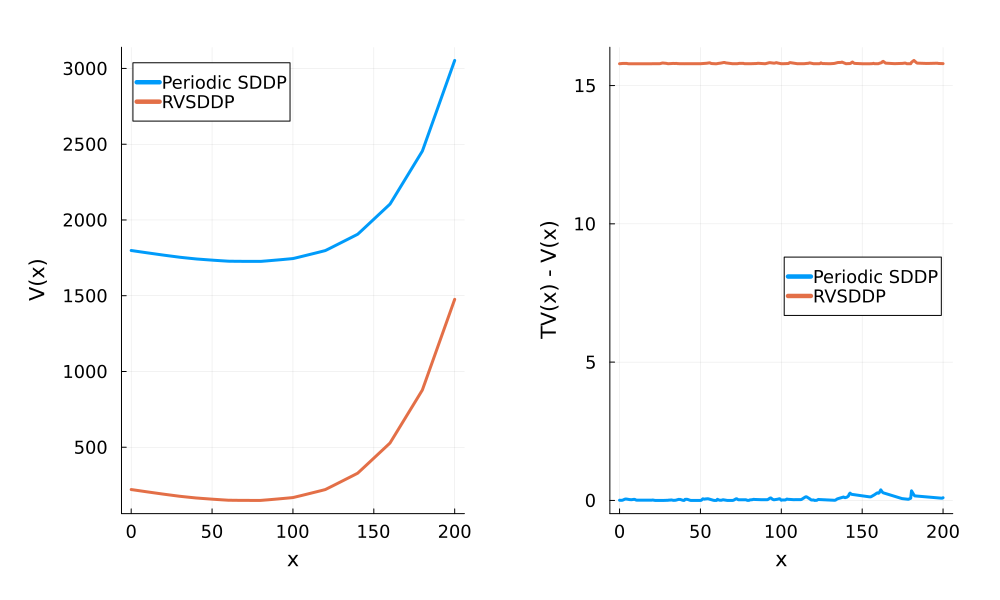

In [10]:
ind = 0:0.5:200
V_no_shift = [RVSDDP.compute_V(model_no_shift[1].value_function, Dict(Symbol("volume[1]")=>1.0*i)) for i in ind]
V_RVSDDP = [RVSDDP.compute_V(model_RVSDDP[1].value_function, Dict(Symbol("volume[1]")=>1.0*i)) for i in ind]

TV_no_shift = [RVSDDP.compute_TV(model_no_shift[1], Dict(Symbol("volume[1]")=>1.0*i)) for i in ind]
TV_RVSDDP = [RVSDDP.compute_TV(model_RVSDDP[1], Dict(Symbol("volume[1]")=>1.0*i)) for i in ind]

p1 = plot(ind, V_no_shift, label="Periodic SDDP", xlabel="x", ylabel="V(x)", 
     guidefontsize=14, tickfontsize=12, legendfontsize=12, linewidth=3,
     margin=10Plots.mm)
plot!(p1, ind, V_RVSDDP, label="RVSDDP", linewidth=3)

p2 = plot(ind, TV_no_shift-V_no_shift, label="Periodic SDDP", xlabel="x", ylabel="TV(x) - V(x)", 
     guidefontsize=14, tickfontsize=12, legendfontsize=12, linewidth=3,
     margin=10Plots.mm, legend=:right)
plot!(p2, ind, TV_RVSDDP-V_RVSDDP, label="RVSDDP", linewidth=3)

plot(p1, p2, layout=(1,2), size=(1000, 600))
# savefig("results_toy/vf_and_TV-V.png")


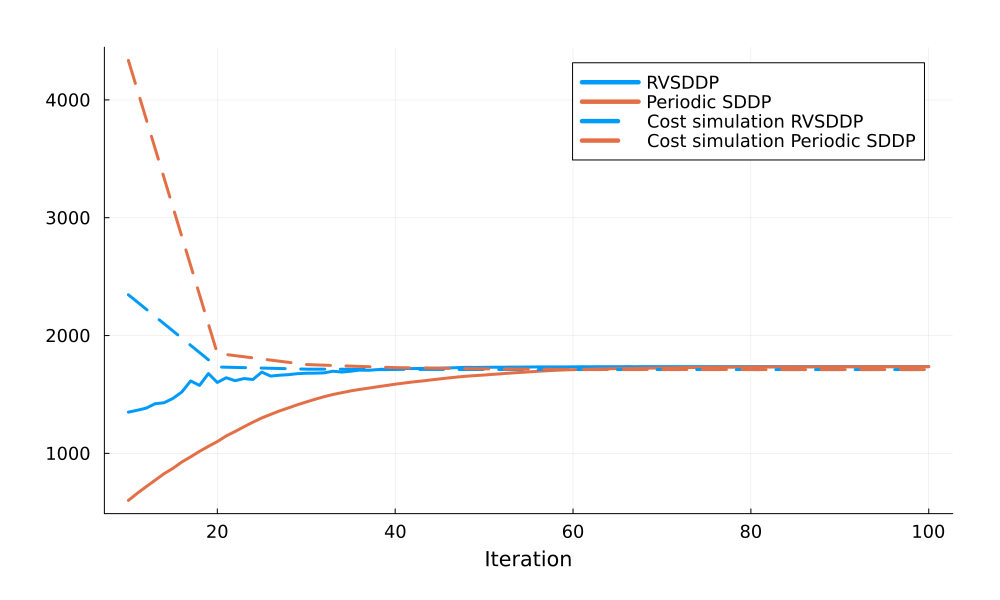

In [13]:
results = Dict()
seed_list = 1:9
iter_max = 100
iter_list_value = 10:100
iter_list_oos = 10:10:100
shift_list = [RVSDDP.no_shift, RVSDDP.shift_update_random_forward]
discount_factor=0.99
period = 1
N=1000
TimeHorizon = Int(round(log(0.001)/log(discount_factor)))
for seed in seed_list
    for shift in shift_list
        folder = "results_toy/$(shift)/$(discount_factor)/seed_$(seed)_iter_$(iter_max)" 
        df_approx_values = CSV.read(joinpath(folder, "approx_values.csv"), DataFrame)
        approx_values = df_approx_values[1:end, :approx_value]
        df_deltas = CSV.read(joinpath(folder, "deltas.csv"), DataFrame)
        deltas = df_deltas[1:end, :delta]
        hat_delta = [RVSDDP.compute_hat_delta([deltas], period, 1, iter, discount_factor) for iter in 1:iter_max]
        oos_df = [CSV.read(joinpath("$(folder)/oos", "oos_horizon_$(iter)_$(TimeHorizon).csv"), DataFrame) for iter in iter_list_oos]
        oos_mean = [mean(oos_df[i][1:end, :oos_horizon]) for i in 1:length(oos_df)]
        oos_std = [std(oos_df[i][1:end, :oos_horizon]) for i in 1:length(oos_df)]
        results[(seed, shift)] = (approx_values, hat_delta, oos_mean, oos_std)
        # results[(seed, shift)] = (approx_values, hat_delta)
    end
end

results_mean = Dict()
for shift in shift_list
    all_approx_values = [results[(seed, shift)][1][iter_list_value] for seed in seed_list]
    all_hat_delta = [results[(seed, shift)][2][iter_list_value] for seed in seed_list]
    all_oos_mean = [results[(seed, shift)][3] for seed in seed_list]
    all_oos_std = [results[(seed, shift)][4] for seed in seed_list]

    # println(length(all_oos))
    # println(all_oos)

    
    # Stack them into matrices for quantile computation
    approx_values_matrix = hcat(all_approx_values...)  # 100 x 10 matrix
    hat_delta_matrix = hcat(all_hat_delta...)  # 100 x 10 matrix
    oos_mean_matrix = hcat(all_oos_mean...)  # 10 x 10 matrix (10 iterations x 10 seeds)
    oos_std_matrix = hcat(all_oos_std...)  # 10 x 10 matrix (10 iterations x 10 seeds)
    
    # Compute quantiles (20%-80%) across seeds for each iteration
    approx_values_20 = [quantile(approx_values_matrix[iter, :], 0.2) for iter in 1:size(approx_values_matrix, 1)]
    approx_values_80 = [quantile(approx_values_matrix[iter, :], 0.8) for iter in 1:size(approx_values_matrix, 1)]
    approx_values_mean = mean(approx_values_matrix, dims=2)[:]
    
    hat_delta_20 = [quantile(hat_delta_matrix[iter, :], 0.2) for iter in 1:size(hat_delta_matrix, 1)]
    hat_delta_80 = [quantile(hat_delta_matrix[iter, :], 0.8) for iter in 1:size(hat_delta_matrix, 1)]
    hat_delta_mean = mean(hat_delta_matrix, dims=2)[:]

    # oos_20 = [quantile(oos_matrix[iter, :], 0.2) for iter in 1:size(oos_matrix, 1)]
    # oos_80 = [quantile(oos_matrix[iter, :], 0.8) for iter in 1:size(oos_matrix, 1)]
    oos_mean = mean(oos_mean_matrix, dims=2)[:]
    oos_std = mean(oos_std_matrix, dims=2)[:]

    results_mean[shift] = (approx_values_20, approx_values_80, hat_delta_20, hat_delta_80, approx_values_mean, hat_delta_mean, oos_mean, oos_std)
end

# Plot with 20%-80% intervals as ribbons
rvsddp_value = results_mean[RVSDDP.shift_update_random_forward][5] + results_mean[RVSDDP.shift_update_random_forward][6]
rvsddp_lower = results_mean[RVSDDP.shift_update_random_forward][1] + results_mean[RVSDDP.shift_update_random_forward][3]
rvsddp_upper = results_mean[RVSDDP.shift_update_random_forward][2] + results_mean[RVSDDP.shift_update_random_forward][4]

periodic_value = results_mean[RVSDDP.no_shift][5]
periodic_lower = results_mean[RVSDDP.no_shift][1]
periodic_upper = results_mean[RVSDDP.no_shift][2]

tcrit = quantile(TDist(N-1), 0.975)

oos_rvsddp_value = results_mean[RVSDDP.shift_update_random_forward][7]
oos_rvsddp_lower = results_mean[RVSDDP.shift_update_random_forward][7] - tcrit * results_mean[RVSDDP.shift_update_random_forward][8] / sqrt(N)
oos_rvsddp_upper = results_mean[RVSDDP.shift_update_random_forward][7] + tcrit * results_mean[RVSDDP.shift_update_random_forward][8] / sqrt(N)

oos_periodic_value = results_mean[RVSDDP.no_shift][7]
oos_periodic_lower = results_mean[RVSDDP.no_shift][7] - tcrit * results_mean[RVSDDP.no_shift][8] / sqrt(N)
oos_periodic_upper = results_mean[RVSDDP.no_shift][7] + tcrit * results_mean[RVSDDP.no_shift][8] / sqrt(N)

# p = plot(iter_list_value, rvsddp_value,
#          ribbon=(rvsddp_value - rvsddp_lower, rvsddp_upper - rvsddp_value),
#          label="RVSDDP", linewidth=2, fillalpha=0.3, guidefontsize=14, tickfontsize=12, legendfontsize=12, size=(1000, 600),
#      margin=10Plots.mm)
# plot!(iter_list_value, periodic_value,
#       ribbon=(periodic_value - periodic_lower, periodic_upper - periodic_value),
#       label="Periodic SDDP", linewidth=2, fillalpha=0.3)
# plot!(iter_list_oos, oos_rvsddp_value,
#       ribbon=(oos_rvsddp_value - oos_rvsddp_lower, oos_rvsddp_upper - oos_rvsddp_value),
#       label="OOS RVSDDP", linewidth=2, fillalpha=0.3)
# plot!(iter_list_oos, oos_periodic_value,
#       ribbon=(oos_periodic_value - oos_periodic_lower, oos_periodic_upper - oos_periodic_value),
#       label="OOS Periodic SDDP", linewidth=2, fillalpha=0.3)
# xlabel!("Iteration")

p = plot(iter_list_value, rvsddp_value,
         label="RVSDDP", linewidth=3, fillalpha=0.3, guidefontsize=14, tickfontsize=12, legendfontsize=12, size=(1000, 600),
     margin=10Plots.mm)
plot!(iter_list_value, periodic_value,
      label="Periodic SDDP", linewidth=3, fillalpha=0.3)
plot!(iter_list_oos, oos_rvsddp_value,
      label="Cost simulation RVSDDP", linewidth=3, fillalpha=0.3, linestyle=:dash, color=1)
plot!(iter_list_oos, oos_periodic_value,
      label="Cost simulation Periodic SDDP", linewidth=3, fillalpha=0.3, linestyle=:dash, color=2)
xlabel!("Iteration")
# savefig("results_toy/Cost.png")
